# ARBOL DE DECISIÓN MULTICLASE
## FUENTE : [kaggle](https://www.kaggle.com/datasets/elikplim/car-evaluation-data-set)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_car = pd.read_csv("D:\Conocimiento Adquiridos\Data Science _ Codigo Bootcamp\Desarrollo_MP\BDS-G3\Dia_5\car_evaluation.csv",header=None)
col_names = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
df_car.columns = col_names
df_car.head(10)

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc
5,vhigh,vhigh,2,2,med,high,unacc
6,vhigh,vhigh,2,2,big,low,unacc
7,vhigh,vhigh,2,2,big,med,unacc
8,vhigh,vhigh,2,2,big,high,unacc
9,vhigh,vhigh,2,4,small,low,unacc


In [3]:
df_car.dtypes

buying      object
maint       object
doors       object
persons     object
lug_boot    object
safety      object
class       object
dtype: object

In [4]:
df_car['class'].value_counts()

unacc    1210
acc       384
good       69
vgood      65
Name: class, dtype: int64

In [5]:
df_car.isna().sum().sum()

0

# CODIFICACIÓN DE VARIABLES CATEGORICAS

In [15]:
pip install category_encoders

   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   ------------------------------- -------- 8.7/11.1 MB 44.6 MB/s eta 0:00:01
   ---------------------------------------- 11.1/11.1 MB 43.5 MB/s eta 0:00:00
  Attempting uninstall: threadpoolctl
    Found existing installation: threadpoolctl 2.2.0
    Uninstalling threadpoolctl-2.2.0:
      Successfully uninstalled threadpoolctl-2.2.0
  Attempting uninstall: joblib
    Found existing installation: joblib 1.1.1
    Uninstalling joblib-1.1.1:
      Successfully uninstalled joblib-1.1.1
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.1
    Uninstalling scikit-learn-1.2.1:
      Successfully uninstalled scikit-learn-1.2.1
Note: you may need to restart the kernel to use updated packages.


In [16]:
import category_encoders as ce

encoder = ce.OrdinalEncoder(cols=df_car.columns)
df_car_encoder = encoder.fit_transform(df_car)
df_car_encoder

,buying,maint,doors,persons,lug_boot,safety,class
0,1,1,1,1,1,1,1
1,1,1,1,1,1,2,1
2,1,1,1,1,1,3,1
3,1,1,1,1,2,1,1
4,1,1,1,1,2,2,1
...,...,...,...,...,...,...,...
1723,4,4,4,3,2,2,4
1724,4,4,4,3,2,3,3
1725,4,4,4,3,3,1,1
1726,4,4,4,3,3,2,4


# ENTRENAMIENTO DEL MODELO

In [34]:
X = df_car_encoder.drop(['class'],axis=1)
y = df_car_encoder['class']

In [35]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.30, random_state = 42)

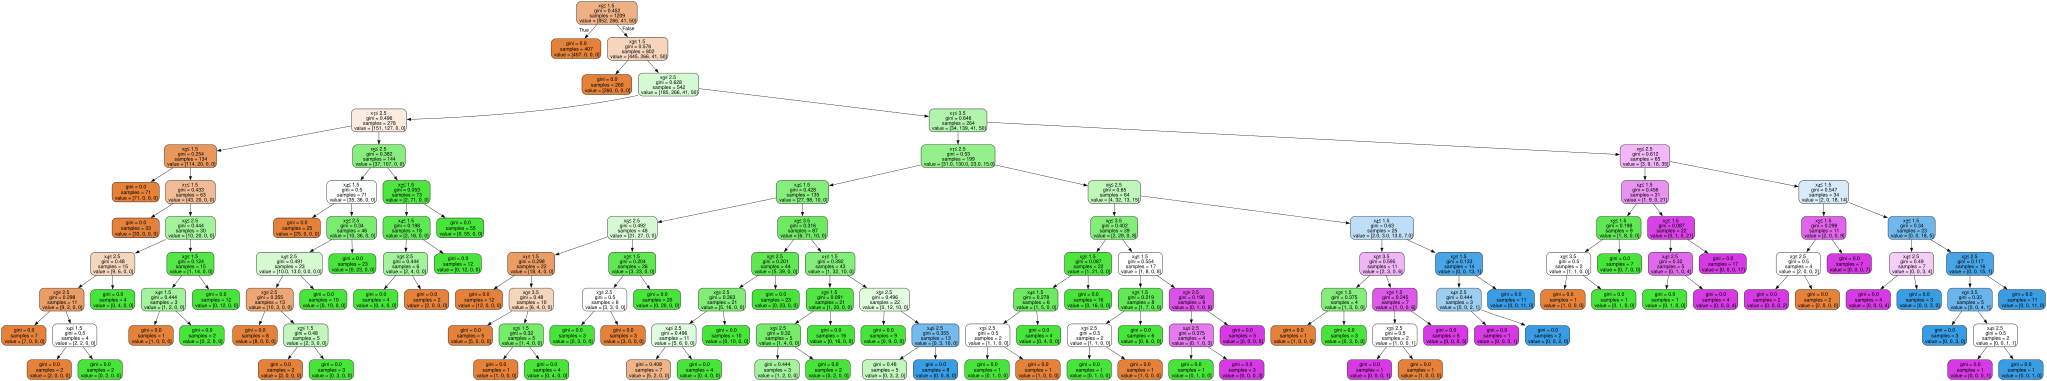

In [43]:
from sklearn.tree import DecisionTreeClassifier, export_graphviz
import graphviz

# Train the decision tree model
tree = DecisionTreeClassifier(max_depth=10, random_state=0)
tree.fit(X_train, y_train)

# Export the decision tree visualization
dot_data = export_graphviz(tree, out_file=None, 
                           filled=True, rounded=True,
                           special_characters=True)  

# Render and display the graph
graph = graphviz.Source(dot_data)  
graph

In [44]:
y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)

# EVALUAMOS EL MODELO

In [45]:
from sklearn.metrics import accuracy_score

train_accuracy_tree = accuracy_score(y_train,y_train_pred)
test_accuray_tree =  accuracy_score(y_test,y_test_pred)

print(f'El accuracy en train es  : {train_accuracy_tree}')
print(f'El accuracy en test es  : {test_accuray_tree}')

El accuracy en train es  : 0.9958643507030603
El accuracy en test es  : 0.9614643545279383


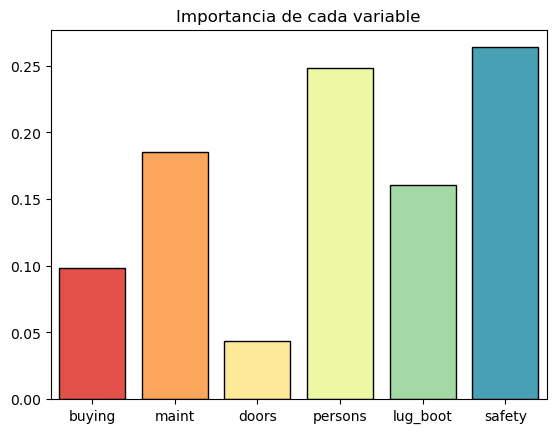

In [46]:
importances = tree.feature_importances_
columns = X.columns
sns.barplot(x=columns,y=importances,palette = 'Spectral', saturation = 2.0, edgecolor ='black', linewidth = 1)
plt.title('Importancia de cada variable')
plt.show()

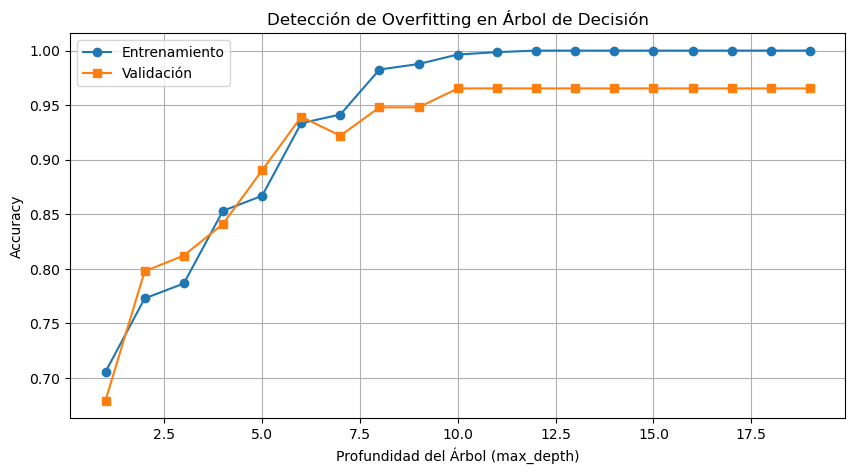

In [47]:
# Datos (usamos X, y de tu dataset)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

train_scores = []
val_scores = []
max_depths = range(1,20)  # Profundidades de 1 a 20

for depth in max_depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    # Evaluamos en los conjuntos de entrenamiento y validación
    train_acc = accuracy_score(y_train, model.predict(X_train))
    val_acc = accuracy_score(y_val, model.predict(X_val))

    train_scores.append(train_acc)
    val_scores.append(val_acc)

# Graficamos las curvas de accuracy
plt.figure(figsize=(10, 5))
plt.plot(max_depths, train_scores, label="Entrenamiento", marker='o')
plt.plot(max_depths, val_scores, label="Validación", marker='s')
plt.xlabel("Profundidad del Árbol (max_depth)")
plt.ylabel("Accuracy")
plt.title("Detección de Overfitting en Árbol de Decisión")
plt.legend()
plt.grid(True)
plt.show()